In [1]:
import os
import cv2
import dlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from imutils import face_utils
from sklearn.metrics import roc_curve, auc

import sys
BASE_PATH = os.path.expanduser("~/100xDevs/personality/Personality-Classifier")
sys.path.append(BASE_PATH)

from src.feature_extraction.geometric_features import extract_cheekbone_ratio

In [2]:
IMAGE_FOLDER = os.path.join(
    BASE_PATH,
    "data/raw/ZipCeleb/img_align_celeba/img_align_celeba"
)

ATTR_PATH = os.path.join(
    BASE_PATH,
    "data/raw/ZipCeleb/list_attr_celeba.csv"
)

PREDICTOR_PATH = os.path.join(
    BASE_PATH,
    "models/landmark_model/shape_predictor_68_face_landmarks.dat"
)

In [3]:
df = pd.read_csv(ATTR_PATH)

TARGET_COLUMN = "High_Cheekbones"   # CelebA label

print("Samples:", len(df))

Samples: 202599


In [4]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(PREDICTOR_PATH)

In [5]:
ratios = []
labels = []

sample_df = df.sample(1000, random_state=42)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    image_name = row["image_id"]
    label = int(row[TARGET_COLUMN])

    image_path = os.path.join(IMAGE_FOLDER, image_name)
    image = cv2.imread(image_path)

    if image is None:
        continue

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 1)

    if len(rects) != 1:
        continue

    shape = predictor(gray, rects[0])
    shape = face_utils.shape_to_np(shape)

    ratio = extract_cheekbone_ratio(shape)

    if ratio is None:
        continue

    ratios.append(ratio)
    labels.append(1 if label == 1 else 0)

100%|██████████| 1000/1000 [00:28<00:00, 34.96it/s]


In [6]:
ratios = np.array(ratios)
labels = np.array(labels)

print("Min:", np.min(ratios))
print("Max:", np.max(ratios))

Min: 0.8916476680519705
Max: 1.0630873149347884


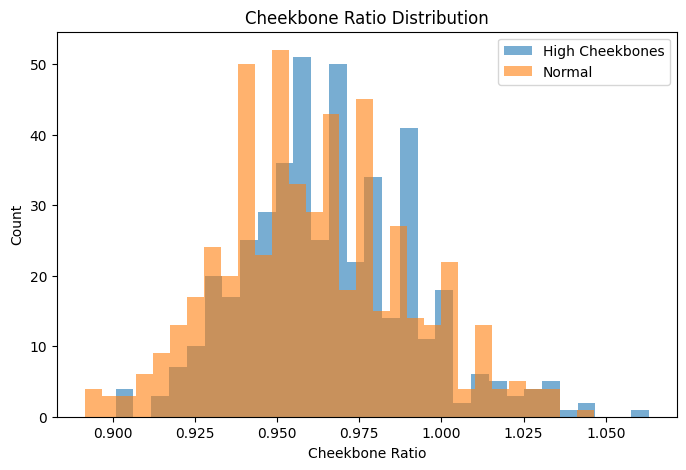

In [7]:
high = ratios[labels == 1]
normal = ratios[labels == 0]

plt.figure(figsize=(8,5))
plt.hist(high, bins=30, alpha=0.6, label="High Cheekbones")
plt.hist(normal, bins=30, alpha=0.6, label="Normal")

plt.legend()
plt.xlabel("Cheekbone Ratio")
plt.ylabel("Count")
plt.title("Cheekbone Ratio Distribution")
plt.show()

In [8]:
mean_high = np.mean(high)
mean_normal = np.mean(normal)

threshold_mean = (mean_high + mean_normal) / 2

print("Mean High:", mean_high)
print("Mean Normal:", mean_normal)
print("Mean Threshold:", threshold_mean)

Mean High: 0.9662073114026314
Mean Normal: 0.9614174799662376
Mean Threshold: 0.9638123956844344


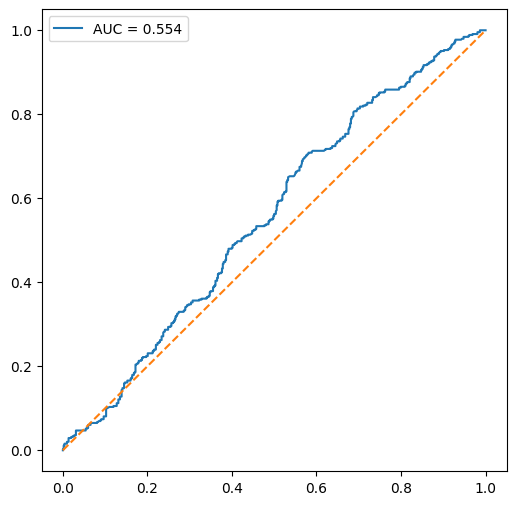

ROC Optimal Threshold: 0.9531656580353186


In [9]:
fpr, tpr, thresholds = roc_curve(labels, ratios)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print("ROC Optimal Threshold:", optimal_threshold)